In [61]:
import soundfile as sf
import matplotlib.pyplot as plt
import math
import numpy as np

In [62]:
waveform, sr = sf.read("audio01.wav", dtype="float32")  # shape (T,), sr=int

In [63]:
waveform.shape

(262094, 2)

In [64]:
def sine(freq_hz, sr, seconds, amp=0.5):
    n = int(sr * seconds)
    return [amp * math.sin(2 * math.pi * freq_hz * i / sr) for i in range(n)]

In [65]:
duration = len(waveform) / sr
duration

5.9431746031746036

In [66]:
def dft(x):
    N = len(x)
    out = []
    for k in range(N):
        re = sum(x[n] * math.cos(-2 * math.pi * k * n / N) for n in range(N))
        im = sum(x[n] * math.sin(-2 * math.pi * k * n / N) for n in range(N))
        out.append((re, im))
    return out

In [68]:
dft_result = np.fft.fft(waveform)

In [69]:
print(type(dft_result))
print(type(dft_result[0]))
print(dft_result[0])

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
[0.+0.j 0.+0.j]


In [70]:

# Sample rate
fs = sr

N = len(dft_result)

frequencies = []
magnitudes = []

for k, (re, im) in enumerate(dft_result):

    # Frequency of this DFT bin
    freq = k * fs / N

    # Magnitude
    magnitude = math.sqrt(re**2 + im**2)

    frequencies.append(freq)
    magnitudes.append(magnitude)

/tmp/ipykernel_49281/1184086802.py:15: ComplexWarning: Casting complex values to real discards the imaginary part
  magnitude = math.sqrt(re**2 + im**2)


<function matplotlib.pyplot.show(close=None, block=None)>

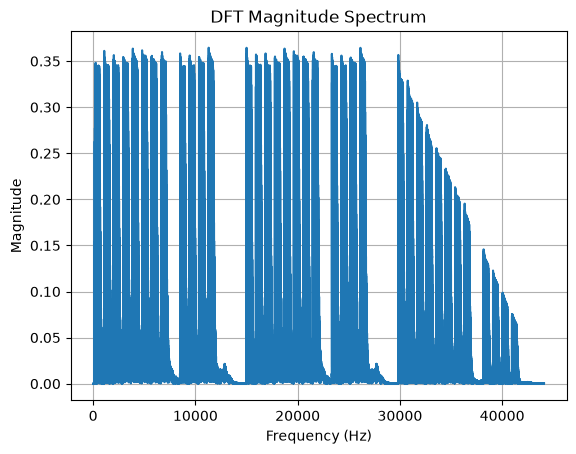

In [71]:
plt.plot(frequencies, magnitudes)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.title("DFT Magnitude Spectrum")
plt.grid()
plt.show